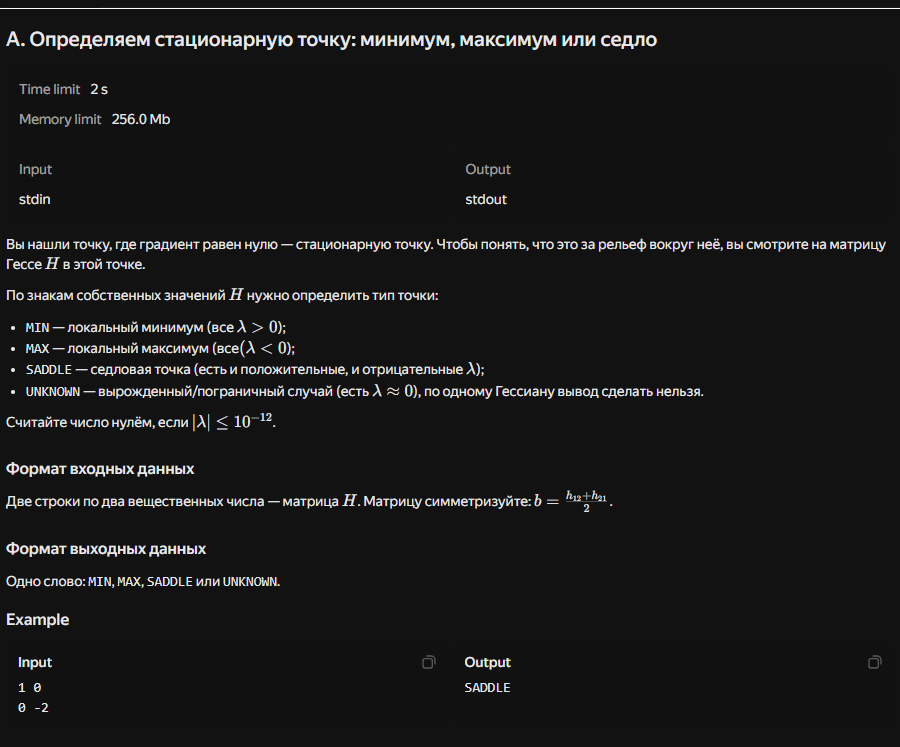

In [3]:
import math

# Наша основная функция
def classify_point(h11, h12, h21, h22):
    b = (h12 + h21) / 2.0
    B = -(h11 + h22)
    C = h11 * h22 - b * b
    
    D = B**2 - 4 * C
    if D < 0:
        D = 0
        
    lambda1 = (-B + math.sqrt(D)) / 2.0
    lambda2 = (-B - math.sqrt(D)) / 2.0
    
    eps = 1e-12
    if abs(lambda1) <= eps or abs(lambda2) <= eps:
        result = "UNKNOWN"
    elif lambda1 > eps and lambda2 > eps:
        result = "MIN"
    elif lambda1 < -eps and lambda2 < -eps:
        result = "MAX"
    else:
        result = "SADDLE"
        
    # Возвращаем не только ответ, но и сами корни, чтобы на них посмотреть
    return result, lambda1, lambda2

# ==========================================
# БЛОК ТЕСТИРОВАНИЯ
# ==========================================
test_cases = [
    (1, 0, 0, -2, "Пример из задачи (Седло)"),
    (2, 0, 0, 3,  "Оба корня положительные (Дно ямы)"),
    (-2, 0, 0, -5, "Оба корня отрицательные (Вершина холма)"),
    (1, 0, 0, 0,  "Один из корней равен нулю (Вырожденный случай)"),
    (0, 5, -5, 0,  "Симметризация (b=0), корни будут нулями")
]

print(f"{'Матрица':<15} | {'λ1':<6} | {'λ2':<6} | {'Результат':<8} | {'Описание'}")
print("-" * 80)

for h11, h12, h21, h22, desc in test_cases:
    res, l1, l2 = classify_point(h11, h12, h21, h22)
    matrix_str = f"[{h11}, {h12}] [{h21}, {h22}]"
    
    # Печатаем красивую таблицу в консоль
    print(f"{matrix_str:<15} | {l1:>6.1f} | {l2:>6.1f} | {res:<8} | {desc}")

Матрица         | λ1     | λ2     | Результат | Описание
--------------------------------------------------------------------------------
[1, 0] [0, -2]  |    1.0 |   -2.0 | SADDLE   | Пример из задачи (Седло)
[2, 0] [0, 3]   |    3.0 |    2.0 | MIN      | Оба корня положительные (Дно ямы)
[-2, 0] [0, -5] |   -2.0 |   -5.0 | MAX      | Оба корня отрицательные (Вершина холма)
[1, 0] [0, 0]   |    1.0 |    0.0 | UNKNOWN  | Один из корней равен нулю (Вырожденный случай)
[0, 5] [-5, 0]  |    0.0 |    0.0 | UNKNOWN  | Симметризация (b=0), корни будут нулями


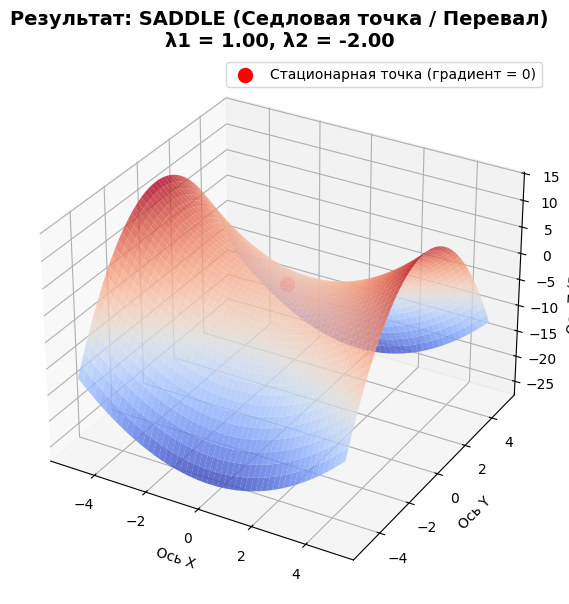

In [4]:
import math
import numpy as np
import matplotlib.pyplot as plt

def analyze_and_plot(h11, h12, h21, h22):
    # --- 1. МАТЕМАТИКА И ЛОГИКА ---
    b = (h12 + h21) / 2.0
    B = -(h11 + h22)
    C = h11 * h22 - b * b
    
    D = B**2 - 4 * C
    if D < 0: D = 0
        
    lambda1 = (-B + math.sqrt(D)) / 2.0
    lambda2 = (-B - math.sqrt(D)) / 2.0
    
    eps = 1e-12
    if abs(lambda1) <= eps or abs(lambda2) <= eps:
        result = "UNKNOWN (Вырожденный случай)"
    elif lambda1 > eps and lambda2 > eps:
        result = "MIN (Локальный минимум / Яма)"
    elif lambda1 < -eps and lambda2 < -eps:
        result = "MAX (Локальный максимум / Вершина)"
    else:
        result = "SADDLE (Седловая точка / Перевал)"
        
    # --- 2. ВИЗУАЛИЗАЦИЯ (3D ГРАФИК) ---
    # Создаем сетку координат от -5 до 5
    x = np.linspace(-5, 5, 50)
    y = np.linspace(-5, 5, 50)
    X, Y = np.meshgrid(x, y)
    
    # Вычисляем высоту Z (рельеф) по формуле квадратичной формы Гессиана
    Z = 0.5 * (h11 * X**2 + 2 * b * X * Y + h22 * Y**2)
    
    # Настраиваем 3D график
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    
    # Рисуем саму поверхность (cmap='coolwarm' сделает ямы синими, а горы красными)
    surf = ax.plot_surface(X, Y, Z, cmap='coolwarm', alpha=0.8, edgecolor='none')
    
    # Рисуем нашу стационарную точку в центре (0,0,0) большим красным шариком
    ax.scatter(0, 0, 0, color='red', s=100, label='Стационарная точка (градиент = 0)')
    
    # Оформляем надписи
    title_text = f"Результат: {result}\nλ1 = {lambda1:.2f}, λ2 = {lambda2:.2f}"
    ax.set_title(title_text, fontsize=14, fontweight='bold')
    ax.set_xlabel('Ось X')
    ax.set_ylabel('Ось Y')
    ax.set_zlabel('Ось Z (Высота)')
    ax.legend()
    
    # Показываем график
    plt.show()

# ==========================================
# ЗАПУСК (Раскомментируй нужный пример, убрав символ # в начале строки)
# ==========================================

# Пример 1: Седло (из твоей задачи)
analyze_and_plot(1, 0, 0, -2)

# Пример 2: Локальный минимум (Дно ямы, раскомментируй строку ниже чтобы увидеть)
# analyze_and_plot(2, 0, 0, 2)

# Пример 3: Локальный максимум (Вершина горы)
# analyze_and_plot(-2, 0, 0, -2)

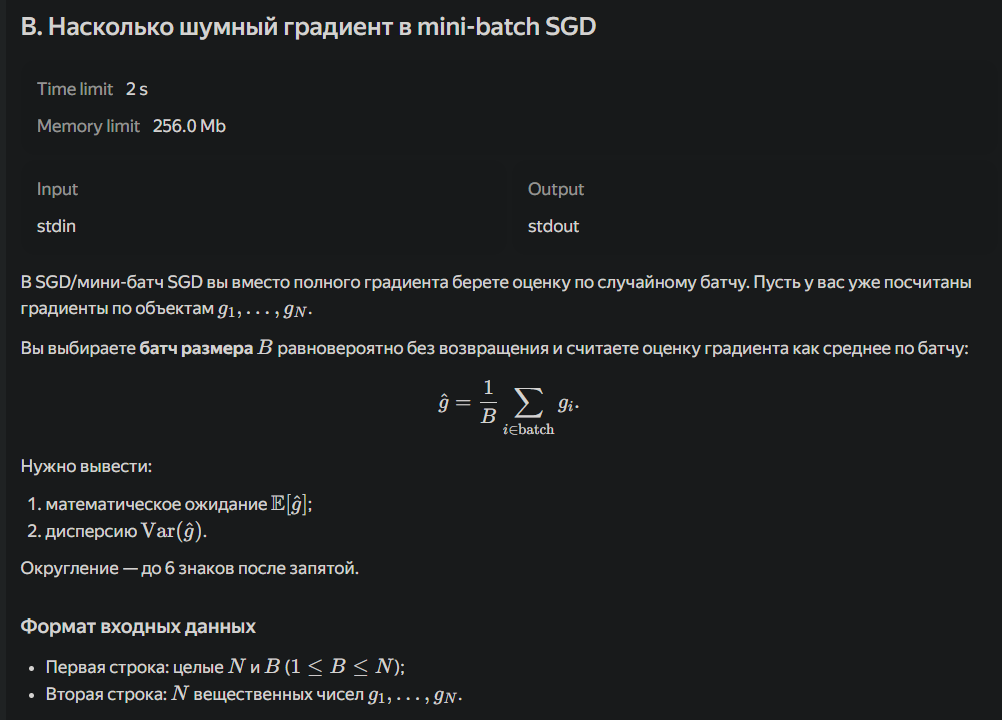
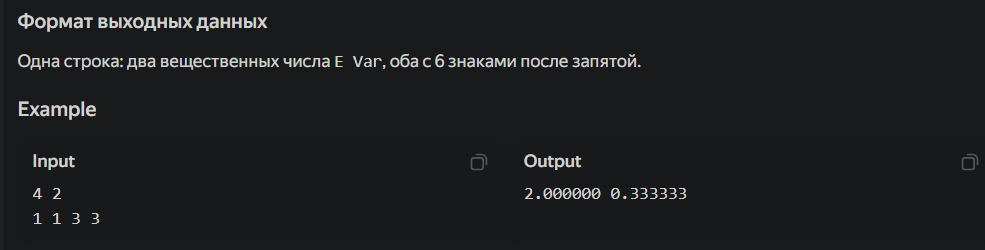

In [5]:
N = 4
B = 2
g = [1, 1, 3, 3]

# 1. Считаем математическое ожидание (E)
sum_g = 0
for val in g:
    sum_g += val
    
E = sum_g / N

# 2. Считаем базовую дисперсию (sigma_sq)
sum_sq_diff = 0
for val in g:
    sum_sq_diff += (val - E)**2
    
sigma_sq = sum_sq_diff / N

# 3. Считаем итоговую дисперсию батча (Var)
Var = (sigma_sq / B) * ((N - B) / (N - 1))

print(E, Var)

2.0 0.3333333333333333


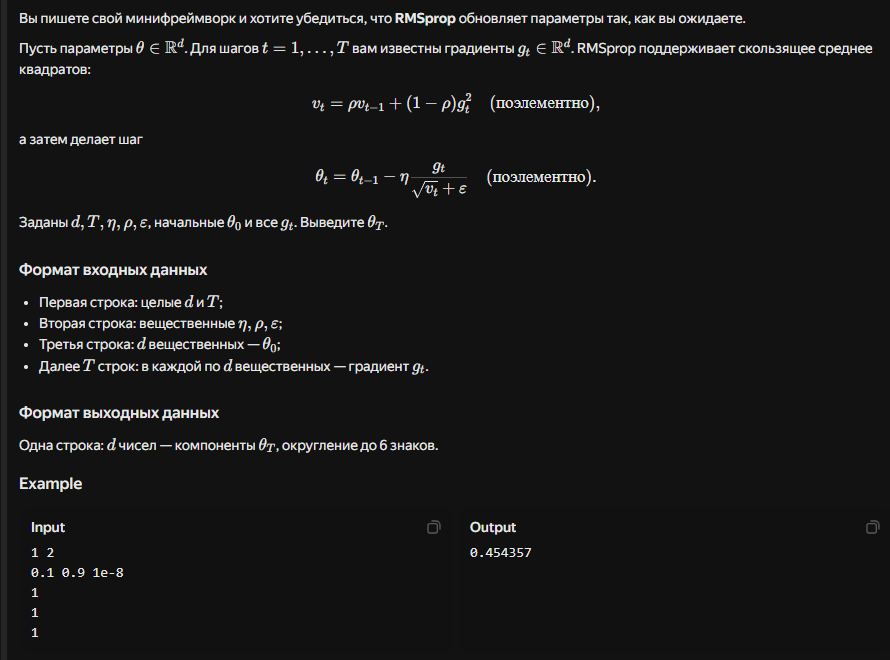

In [1]:
import sys
import math

def main():
    # 1. Читаем абсолютно все данные с сервера
    data = sys.stdin.read().split()
    if not data:
        return
        
    d = int(data[0])
    T = int(data[1])
    
    eta = float(data[2])
    rho = float(data[3])
    eps = float(data[4])
    
    # 2. Вырезаем стартовые параметры theta_0 
    # Они лежат начиная с 5-го элемента, и их ровно d штук
    theta = [float(x) for x in data[5 : 5+d]]
    
    # Создаем стартовую память (чистые нули)
    v = [0.0] * d
    
    # Нам нужно знать, откуда начинать читать градиенты в списке data
    idx = 5 + d 
    
    # 3. Главный цикл на T шагов
    for t in range(T):
        # Вырезаем градиенты для текущего шага
        g = [float(x) for x in data[idx : idx+d]]
        idx += d # Сдвигаем индекс для следующего шага
        
        # Обновляем каждый параметр поэлементно
        for i in range(d):
            # Шаг 1: Обновляем скользящее среднее квадратов
            v[i] = rho * v[i] + (1.0 - rho) * (g[i] ** 2)
            
            # Шаг 2: Обновляем сами параметры (веса)
            theta[i] = theta[i] - eta * g[i] / (math.sqrt(v[i]) + eps)
            
    # 4. Вывод результата. 
    # Проходим по всем итоговым theta, форматируем (6 знаков) и склеиваем через пробел
    result = " ".join(f"{x:.6f}" for x in theta)
    print(result)

if __name__ == '__main__':
    main()

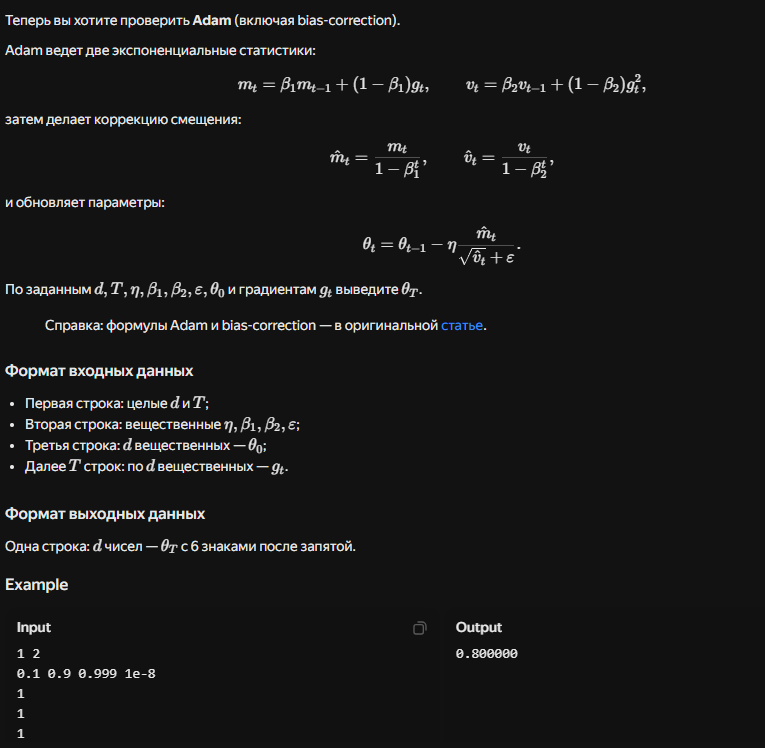

In [2]:
import sys
import math

def main():
    # 1. Читаем все данные
    data = sys.stdin.read().split()
    if not data:
        return
        
    d = int(data[0])
    T = int(data[1])
    
    eta = float(data[2])
    beta1 = float(data[3])
    beta2 = float(data[4])
    eps = float(data[5])
    
    # 2. Вырезаем стартовые веса theta (начинаются с индекса 6)
    theta = [float(x) for x in data[6 : 6+d]]
    
    # Создаем ДВЕ стартовые памяти (чистые нули)
    m = [0.0] * d
    v = [0.0] * d
    
    idx = 6 + d
    
    # 3. Главный цикл. 
    # ВАЖНО: range(1, T + 1) значит, что t будет идти от 1 до T включительно.
    for t in range(1, T + 1):
        # Вырезаем градиенты для текущего шага
        g = [float(x) for x in data[idx : idx+d]]
        idx += d
        
        # Обновляем каждый параметр поэлементно
        for i in range(d):
            # Шаг 1: Накапливаем статистику (экспоненциальное скользящее среднее)
            m[i] = beta1 * m[i] + (1.0 - beta1) * g[i]
            v[i] = beta2 * v[i] + (1.0 - beta2) * (g[i] ** 2)
            
            # Шаг 2: Делаем Bias Correction (коррекцию смещения для старта)
            # Возводим беты в степень t
            m_hat = m[i] / (1.0 - beta1 ** t)
            v_hat = v[i] / (1.0 - beta2 ** t)
            
            # Шаг 3: Обновляем сами параметры, используя исправленные m_hat и v_hat
            theta[i] = theta[i] - eta * m_hat / (math.sqrt(v_hat) + eps)
            
    # 4. Вывод результата
    result = " ".join(f"{x:.6f}" for x in theta)
    print(result)

if __name__ == '__main__':
    main()

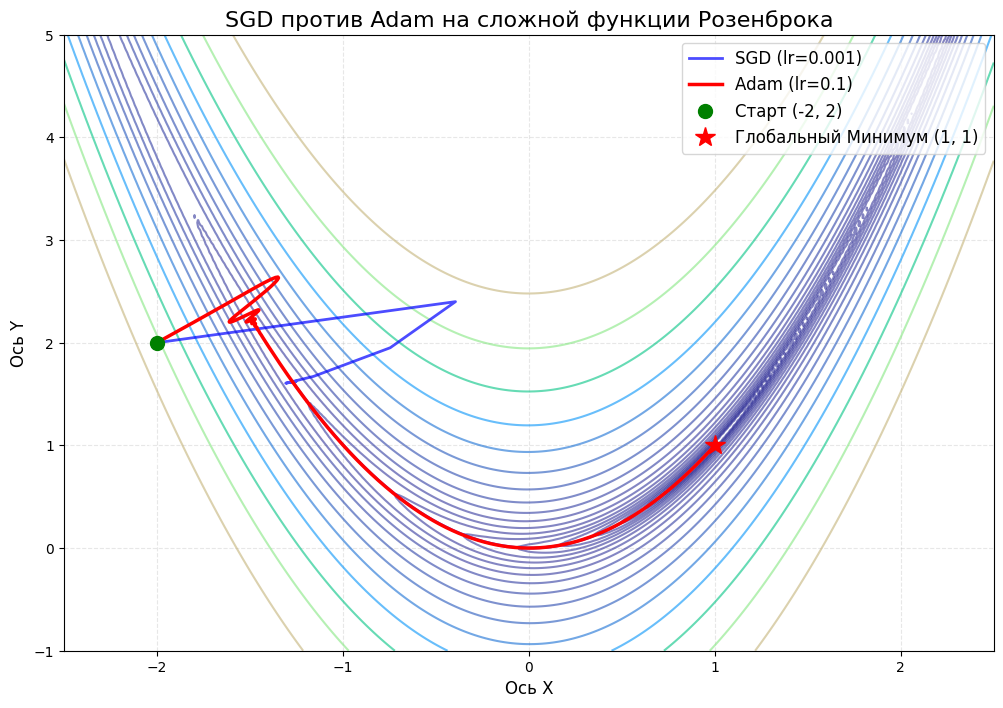

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. ОПИСАНИЕ ЛАНДШАФТА (Функция Розенброка) ---
def rosenbrock(x, y):
    # Сама функция (долина с изогнутым оврагом)
    return (1 - x)**2 + 100 * (y - x**2)**2

def grad_rosenbrock(x, y):
    # Производные (градиенты) по оси X и Y
    dx = -2 * (1 - x) - 400 * x * (y - x**2)
    dy = 200 * (y - x**2)
    return np.array([dx, dy])

# --- 2. СИМУЛЯТОРЫ АЛГОРИТМОВ ---
def run_sgd(start_pos, lr, iterations):
    pos = np.array(start_pos, dtype=float)
    path = [pos.copy()]
    
    for _ in range(iterations):
        grad = grad_rosenbrock(pos[0], pos[1])
        pos -= lr * grad  # Просто шаг вниз по уклону
        path.append(pos.copy())
        
    return np.array(path)

def run_adam(start_pos, lr, iterations, beta1=0.9, beta2=0.999, eps=1e-8):
    pos = np.array(start_pos, dtype=float)
    path = [pos.copy()]
    m = np.zeros(2)
    v = np.zeros(2)
    
    for t in range(1, iterations + 1):
        grad = grad_rosenbrock(pos[0], pos[1])
        
        m = beta1 * m + (1 - beta1) * grad
        v = beta2 * v + (1 - beta2) * (grad**2)
        
        m_hat = m / (1 - beta1**t)
        v_hat = v / (1 - beta2**t)
        
        pos -= lr * m_hat / (np.sqrt(v_hat) + eps) # Умный шаг
        path.append(pos.copy())
        
    return np.array(path)

# --- 3. ЗАПУСК ГОНКИ ---
start_pos = [-2.0, 2.0] # Начинаем сверху слева
iterations = 2500

# ВНИМАНИЕ: Для обычного SGD на этой функции скорость обучения должна быть
# крошечной (0.001), иначе он "взорвется" и улетит в бесконечность из-за крутых стен!
path_sgd = run_sgd(start_pos, lr=0.001, iterations=iterations)

# Adam справляется гораздо лучше, ему можно дать скорость побольше (0.1)
path_adam = run_adam(start_pos, lr=0.1, iterations=iterations)

# --- 4. ВИЗУАЛИЗАЦИЯ ---
# Создаем сетку координат для карты
x_grid = np.linspace(-2.5, 2.5, 250)
y_grid = np.linspace(-1.0, 5.0, 250)
X, Y = np.meshgrid(x_grid, y_grid)
Z = rosenbrock(X, Y)

plt.figure(figsize=(12, 8))

# Рисуем изолинии (как на топографической карте). logspace нужен из-за крутых склонов
plt.contour(X, Y, Z, levels=np.logspace(-1, 3, 20), cmap='terrain', alpha=0.6)

# Рисуем пути алгоритмов
plt.plot(path_sgd[:, 0], path_sgd[:, 1], label='SGD (lr=0.001)', color='blue', alpha=0.7, linewidth=2)
plt.plot(path_adam[:, 0], path_adam[:, 1], label='Adam (lr=0.1)', color='red', linewidth=2.5)

# Отмечаем старт и финиш
plt.plot(*start_pos, 'go', markersize=10, label='Старт (-2, 2)')
plt.plot(1, 1, 'r*', markersize=15, label='Глобальный Минимум (1, 1)')

# Оформление
plt.title('SGD против Adam на сложной функции Розенброка', fontsize=16)
plt.xlabel('Ось X', fontsize=12)
plt.ylabel('Ось Y', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)

plt.show()